# Simple Maths Refresher 01

It's been a while since I last thought about A'level maths/stats, so this is a basic run through of some concepts to refresh memory.

Examples will be done in python.

In [5]:
# import packages and functions
import numpy as np
import matplotlib.pyplot as plt



x values: [-5 -4 -3 -2 -1  0  1  2  3  4  5]
y values: [-9 -7 -5 -3 -1  1  3  5  7  9 11]


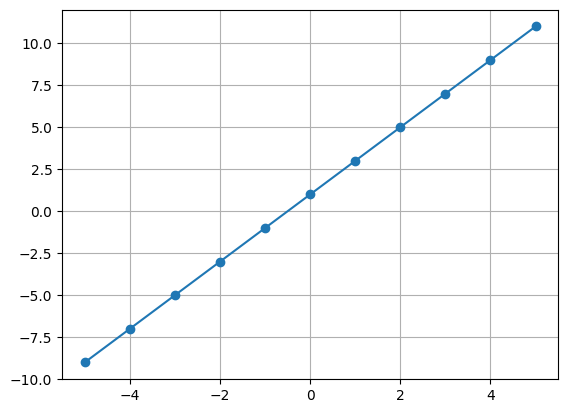

In [6]:
x = np.arange(-5, 6)

y = 2 * x + 1

print("x values:", x)
print("y values:", y)

plt.plot(x, y, marker="o")
plt.grid()
plt.show()

Q. What answer do we get for y when $ x = 4 $ using $ y = 2*x + 1 $?

Answer: 
    $$
    y = 2x + 1 \\
    y = 2(4) + 1 \\
    y = 8 + 1 \\
    y = 9 
    $$

Q. Change the equation to $ y = 3*x + 1 $.  

* What is y now?
* What happens to the line?  (Steeper? Flatter? Moves up or down?  SOmething else?)

Answer: $$
    y = 3x + 1 \\  
    y = 3(4) + 1 \\ 
    y = 12 + 1  \\
    y = 13
    $$

If y = 13, where previously it was 9, then the line becomes steeper.

Moving on, have a look at the chart generated from the following:

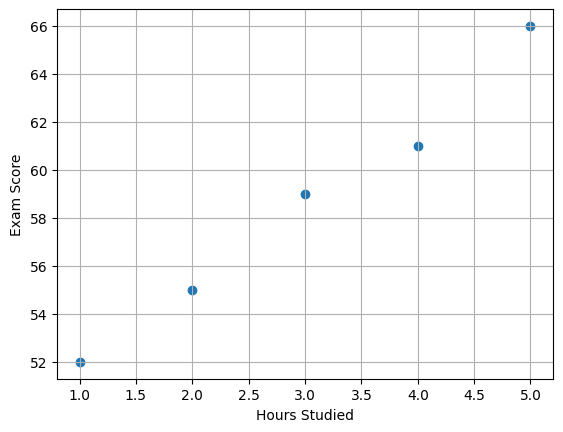

In [7]:
hours = [1, 2, 3, 4, 5]
score = [52, 55, 59, 61, 66]

plt.scatter(hours, score)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.grid()
plt.show()

Conclusions we can draw:
* The points trend upwards
* This suggests that exam score increases with hours studied
* The relationship is roughly a straight line

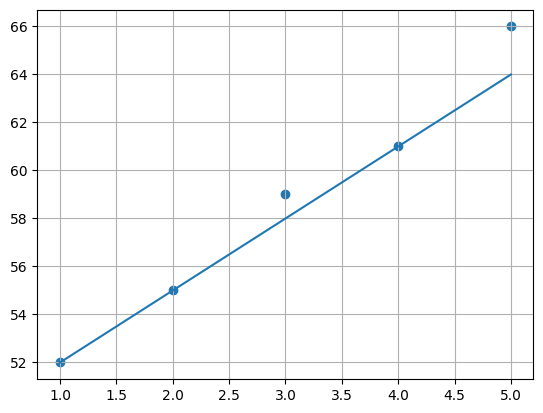

In [8]:
# let's plot a chart using an equation:
x = np.arange(1, 6)
y = 3 * x + 49 # gives us the slope

plt.scatter(hours, score)
plt.plot(x, y)
plt.grid()
plt.show()

Conclusions:

* When looking at the line, it seems to pass through most of the points and is close to the others
* If anything, the line is slightly below the points
* As a model, this is reasonable

This is the essence of predictive modelling (specifically linear regression).  Machine learning automates the process of trying to find a line that best fits the data.

### Measuring Error

Let's create some data to demonstrate how predictions can be good, but not perfect...

In [9]:
# create some data to play with - a set of hours (1-5) and some actual hours worked.
hours = [1, 2, 3, 4, 5]
actual = [52, 55, 59, 61, 66]
# create an empty list to store predicted results
predicted = []
# for each element in the hours object, give me a predicted value based on an equation (our slope from above)
for x in hours:
    predicted.append(3 * x + 49)
# print the results
print("Actual   :", actual)
print("Predicted:", predicted)

Actual   : [52, 55, 59, 61, 66]
Predicted: [52, 55, 58, 61, 64]


OK, so just eyballing our predicted values we can see that they are close (but not exact).  Let's look att he differences between our actual hours worked and our predicted hours worked:

In [15]:
# this will take both our lists and combine them into a single list of tuples, then deduct the elements in order
for a, p in zip(actual, predicted):
    print(a - p)


0
0
1
0
2


The above differences in values represent **error** - values here represent how incorrect our predictions were.

The model isn't outrageously inaccurate, but generally predicts values that are lower than the actual.

### Let's test our hypothesis

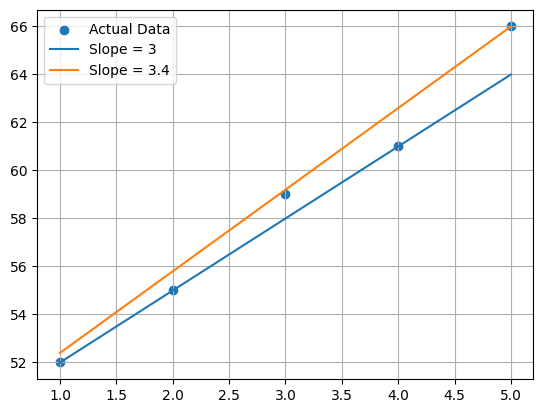

In [16]:
# recreate our data
hours = [1, 2, 3, 4, 5]
actual = [52, 55, 59, 61, 66]

x = np.arange(1, 6)

# add the original line and a new, slightly adjusted, line
y1 = 3 * x + 49
y2 = 3.4 * x + 49

# plot both our actual points and our new lines
plt.scatter(hours, actual, label="Actual Data")
plt.plot(x, y1, label="Slope = 3")
plt.plot(x, y2, label="Slope = 3.4")

plt.legend()
plt.grid()
plt.show()

We've slightly adjusted, but now it seems that both the starting point (the intercept) and the slope are too high.  This raises a good point - by adjusting the slope we've impacted the intercept and how the line passes through the first data points.

Let's try again:

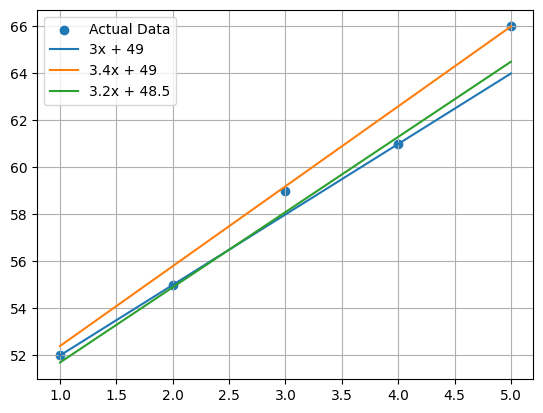

In [17]:
hours = [1, 2, 3, 4, 5]
actual = [52, 55, 59, 61, 66]

x = np.arange(1, 6)

plt.scatter(hours, actual, label="Actual Data")

plt.plot(x, 3*x + 49, label="3x + 49")
plt.plot(x, 3.4*x + 49, label="3.4x + 49")
plt.plot(x, 3.2*x + 48.5, label="3.2x + 48.5")

plt.legend()
plt.grid()
plt.show()

We've made further adjustments but again it's not quite right.

We can now see that adjusting the intercept will raise or lower the line, where adjusting the slope will make the line more or less steep.

The intercept, here 49, is the value we would expect to see if x was 0.  While this is a mathematically correct statement, as a data scientist we must also be capable of relating this to the real world meaning: i.e. that if someone didn't study at all, they could expect to recieve ~49 marks. 

Slope: 3.4000000000000004
Intercept: 48.4


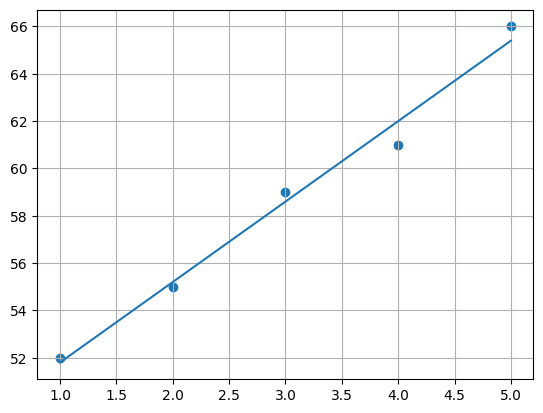

In [18]:
from sklearn.linear_model import LinearRegression

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([52, 55, 59, 61, 66])

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

plt.scatter(X, y)

x_line = np.linspace(1, 5, 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.plot(x_line, y_line)
plt.grid()
plt.show()

This tells us that python found a lope of 3.4 with an intercept of 48.4, which means our guesses were pretty good.

## Let's quantify "good"

In other words, how 'good' is our model?

In [19]:
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([52, 55, 59, 61, 66])

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

print(predictions)

[51.8 55.2 58.6 62.  65.4]


We've fit a model on some basic data and made some predictions.  But how accurate are those predictions?

Let's ahve a look at the residuals first:

In [20]:
residuals = y - predictions

print(residuals)

[ 0.2 -0.2  0.4 -1.   0.6]


The residuals are the differences between our predictions and the actual values.  Evaluating how good our model effectively means understanding the residuals and their relationship to the variables we used to train the model.

If:

    residual > 0 → model predicted too low
    residual < 0 → model predicted too high
    residual = 0 → perfect prediction

This is exactly the same residual concept I've already been using in my student grades project.

In [21]:
print("Mean residual:", residuals.mean())

Mean residual: -1.4210854715202005e-15


The mean of our residuals is so small it is effectively 0, which we would expect as they are a mixture of both positive and negative values (above and below our line of bet fit).

### Root Mean Square Error

Taking this a little further, if we square the errors before we calculate the mean we will make them all positive - which will give us a metric of variance from the model's prediction:

In [22]:
squared_residuals = residuals ** 2

print(squared_residuals)
print("MSE:", squared_residuals.mean())

[0.04 0.04 0.16 1.   0.36]
MSE: 0.31999999999999884


For argument's sake, let's say we have two models: A and B.

* model A predicts two values and the residuals for those two values are [1, 1]
* model b predicts two values and the residuals for those two values are [100, 100]

If we relied purely on the mean of the residuals then both models would have a mean of 1, making them seem equally effective.  However, we can immediately tell that B is much worse at predicting than A as looking at the residuals tells us that both values B predicted are 100 units of error away from the actual values, where A's values are only 1 unit away.

Squaring these values before calculating the mean would make all values positive before we add them together and take an average.  This means our MSE would be:

* A: mean = 1 : i.e. $ (1)^2 + (1)^2 / 2 $
* B: mean = 10,000 : i.e. $ (100)^2 + (100)^2 / 2 $

But, if we did that then we have to remember that the resulting metrics are squared - this can make it a little harder to interpret than it needs to be...

If we square root the MSE we will get the average distance the actual values are from the predicted values **in the same units as the response variable**, making this very easy to interpret.

Finishing off this example, the RMSE (root mean squared error) would be 100 : i.e. $ \sqrt 1000 $

Going back to our worked example:


In [23]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, predictions)

print("MSE:", mse)

MSE: 0.31999999999999884


In [ ]:
The MSE here is 0.3199, which is a squared value.

In [24]:
rmse = np.sqrt(mean_squared_error(y, predictions))

print("RMSE:", rmse)

RMSE: 0.565685424949237


So, using RMSE, our model is approximately 0.57 units off.